# Snow-Underlay — analysis notebook

> *Constants as the bridge.* Generalisation, not memorisation.
> SoTA Commission I — Minimal-Shot Autonomy.

This notebook is the **thinking** behind the Snow-Underlay submission — exploration, data inspection, the pipeline traced through one frame qualitatively, what we tried and rejected, design decisions, generalisation, and the minimal-shot integrity audit. It is not a benchmark notebook; it does not report quoted percentages or IoU scores, because the project has no labelled ground truth to score against. It is the work, with the work shown.

The headline artefact lives in `outputs/video/boreas_2021_01_26/overlay.mp4` (run `make reproduce` to produce it from a clean clone). This notebook walks through *how* it was produced and *what we learned*.

## 1 · The principle, in one paragraph

Minimal-shot autonomy is the question of how a perception system survives in regimes it has not been heavily trained on. The default answer is *collect more data and retrain*. Labelling cannot keep pace with reality.

There is a different move available, and it does not require new training data. **For almost every operating regime where autonomy fails for lack of data, there is an adjacent regime — temporally, seasonally, geographically — where data exists, and where the parts that matter are the same.** A snow plough's road is the same road it was last July. The road's *appearance* has changed; its *position in space* has not.

The contribution this notebook explores is not a snow plough. It is a primitive — **the constants-bridge** — a composition that takes a model trained on regime A, an inference target in regime B, and a known invariant between A and B, and uses the invariant to transfer the model into B without retraining.

Snow on a road is one consumer of this primitive.

## 2 · Data inspection

We load one canonical (snow, summer) pair from the demo set. The two images are taken at the same physical place in different seasons. The matcher's job is to find what the season has not changed.

using pair: gallivare_se__1074104257224613__317074743121442


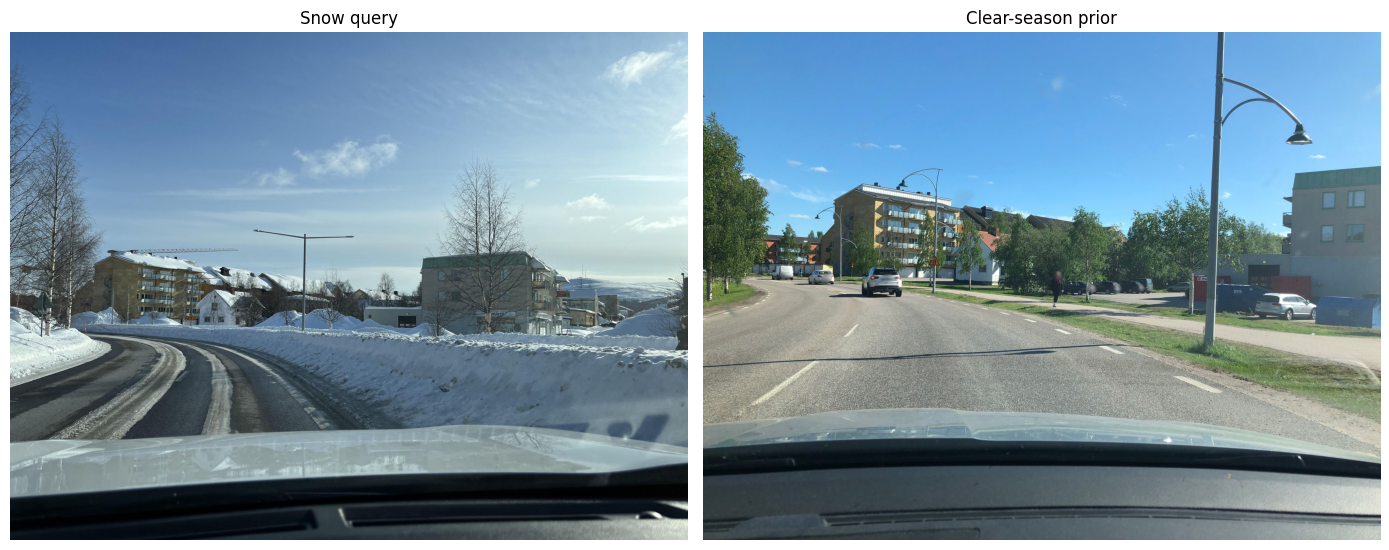

In [1]:
import sys
from pathlib import Path

def _find_root(start: Path) -> Path:
    cur = start.resolve()
    for p in [cur, *cur.parents]:
        if (p / 'pyproject.toml').exists():
            return p
    raise RuntimeError(f'Could not find pyproject.toml above {cur}')

ROOT = _find_root(Path.cwd())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
import cv2
import matplotlib.pyplot as plt

# Pick the first demo pair on disk that has both snow and clear images.
# Run `make stills-fetch` first if no pairs are present (fresh clones).
candidates = sorted((ROOT / 'data/pairs').iterdir()) if (ROOT / 'data/pairs').is_dir() else []
PAIR_DIR = next(
    (p for p in candidates if p.is_dir() and (p / 'snow.jpg').exists() and (p / 'clear.jpg').exists()),
    None,
)
if PAIR_DIR is None:
    raise RuntimeError(
        f'No demo pairs found under {ROOT}/data/pairs. '
        'Run `make stills-fetch` (needs MAPILLARY_TOKEN) from the repo root, '
        'then re-execute this notebook.'
    )
print(f'using pair: {PAIR_DIR.name}')

snow = cv2.cvtColor(cv2.imread(str(PAIR_DIR / 'snow.jpg')), cv2.COLOR_BGR2RGB)
clear = cv2.cvtColor(cv2.imread(str(PAIR_DIR / 'clear.jpg')), cv2.COLOR_BGR2RGB)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].imshow(snow);  axes[0].set_title('Snow query');  axes[0].axis('off')
axes[1].imshow(clear); axes[1].set_title('Clear-season prior'); axes[1].axis('off')
plt.tight_layout(); plt.show()


The two regimes look different. The road in the snow image is a flat white surface; in the prior, the road has lane markings, kerbs, sometimes wet asphalt under cloud. Buildings, fences, and the corner of a red house, however — those are present in both. Those are the constants the matcher can anchor on.

## 3 · The pipeline, traced through one frame

We walk the recipe (snow + clear → matched correspondences → homography → warped road mask → overlay) qualitatively. No quality metrics; the intent is to make the dataflow visible.

Loaded LightGlue model


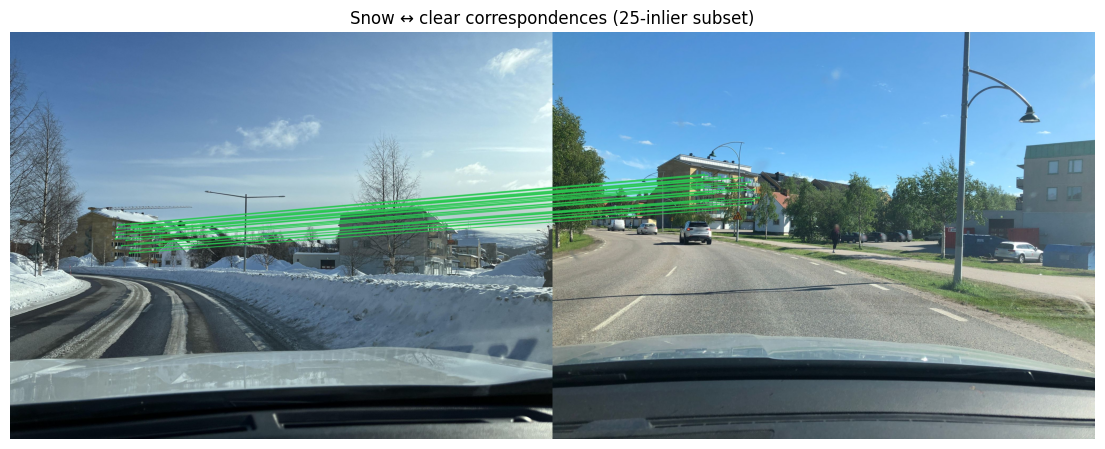

In [2]:
from src.matching import Matcher, draw_matches
from src.homography import estimate

matcher = Matcher()
match_result = matcher.match(snow, clear)
homo = estimate(match_result, snow.shape[:2], clear.shape[:2])

canvas = draw_matches(
    snow, clear, match_result,
    inlier_mask=homo.inlier_mask,
    max_inliers=25, max_outliers=0,
)
plt.figure(figsize=(14, 6)); plt.imshow(canvas); plt.axis('off')
plt.title('Snow ↔ clear correspondences (25-inlier subset)')
plt.show()

The lines connect features the season has not changed: gate posts, fence wires, masonry corners, the corner of a roof or a window frame. There are no correspondences on the road surface itself — the snow has erased the lane markings and the kerb, and the matcher knows there is nothing to anchor on there. That is fine, because we are not trying to match road to road; we are using the constants on the buildings and fences to fix the *geometry*, then using the geometry to bring the *clear* image's road mask back to the snow image's pixel space.

python(84621) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


python(84645) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


Loading weights:   0%|          | 0/566 [00:00<?, ?it/s]

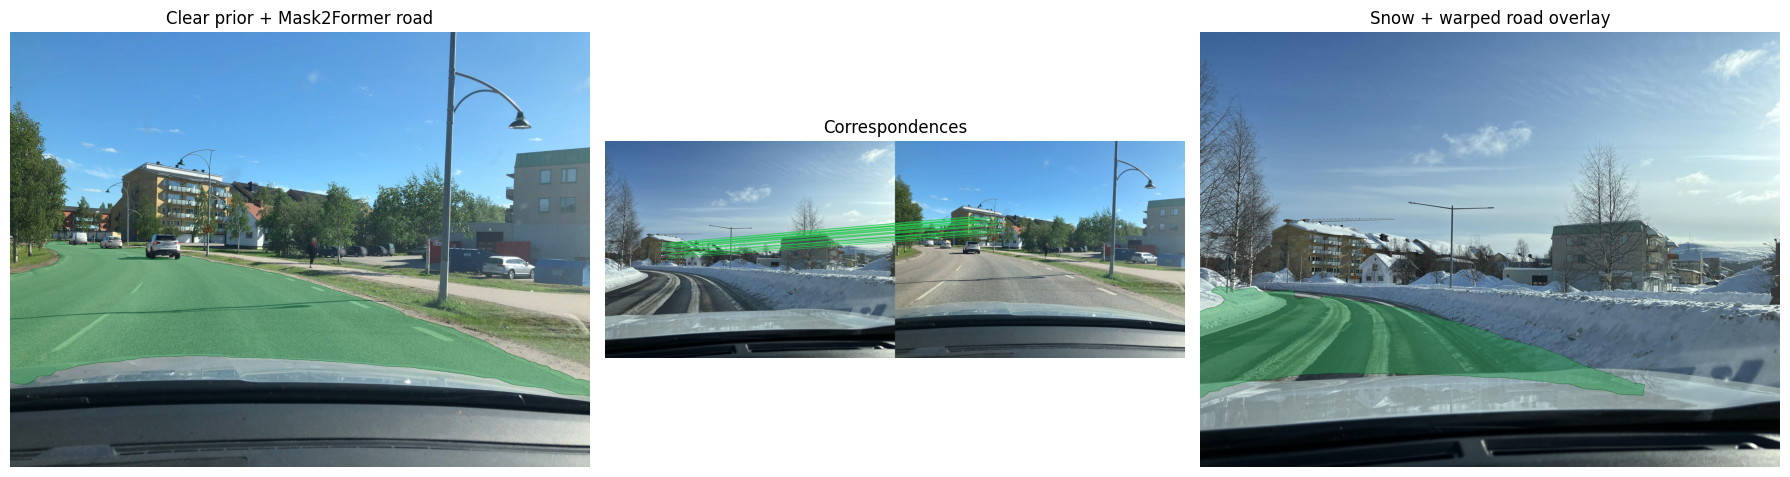

In [3]:
from src.segmentation import RoadSegmenter
from src.overlay import warp_mask, alpha_blend, keep_largest_component

seg = RoadSegmenter()
road_mask_clear = seg.segment_road(clear)
road_mask_clear = keep_largest_component(road_mask_clear)

H_inv = np.linalg.inv(homo.H)
road_mask_snow = warp_mask(road_mask_clear, H_inv, snow.shape[:2])
road_mask_snow = keep_largest_component(road_mask_snow)

overlay = alpha_blend(snow, road_mask_snow, color=(46, 156, 86), alpha=0.50)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].imshow(alpha_blend(clear, road_mask_clear, color=(46, 156, 86), alpha=0.50))
axes[0].set_title('Clear prior + Mask2Former road'); axes[0].axis('off')
axes[1].imshow(canvas); axes[1].set_title('Correspondences'); axes[1].axis('off')
axes[2].imshow(overlay); axes[2].set_title('Snow + warped road overlay'); axes[2].axis('off')
plt.tight_layout(); plt.show()

The plough now knows where the road is. Mask2Former — frozen on Cityscapes, never shown snow — produced the green mask on the clear image; the homography estimated from constants visible in both seasons brought it onto the snow frame. No model in the pipeline ever ran on a snowy image during training.

## 4 · Why the matcher anchors on what it does

The matcher's success is not an accident. The features it picks are the ones that remain visually similar across the seasons. Buildings have planar facades with masonry detail; signs have letter shapes that DISK's local descriptor latches onto; rooflines have geometric corners. Snow does not change those. What snow changes — texture of road, lane markings, the line where pavement meets garden — is exactly what DISK *cannot* find correspondences for, because there is nothing visually consistent to find.

This is a property the brief calls out: *generalisation through visual understanding, not memorisation*. The matcher is not generalising "snow" — it has not been trained on snow. It is generalising *what stays the same*. The architecture of the contribution is to make that generalisation load-bearing.

## 5 · The video extension

The static demo above is one frame. The video extension wraps the same per-pair pipeline in three thin layers:

- A **track loader** indexes a snow stream and a paired summer stream by GPS pose.
- A **prior pool** picks the K = 3 nearest summer captures by UTM distance for each snow frame and caches each prior's Mask2Former road mask once. Multi-prior fusion smooths out per-prior aliasing.
- An **EMA temporal smoother** runs over the binary mask, suppressing per-frame jitter without introducing the drift we saw with optical-flow propagation (see § 6).

A pickled cache layer makes the matching pass reusable: subsequent renders that change only the smoother or the layout skip the matching pass entirely. The cache build for a 350-frame track is matcher-dominated; everything downstream is cheap.

The full canonical 15-second clip is at `outputs/video/boreas_2021_01_26/overlay.mp4` (or run `make reproduce`). This notebook focuses on the static evidence; the moving evidence is the headline.

## 6 · What we tried that did not work

Three negative findings. All three are honest — they look like they should work, they don't, and the reason is the same: a positive feedback loop the static stills hide.

**Synthetic priors from past frames.** Snow→snow matching gives many more inliers per pair than snow→summer because the lighting, lens, and viewpoint conditions are identical between consecutive snow frames. In single-frame stills the resulting mask was visibly broader and more confident. In motion, each frame's slightly-too-large mask seeded the next frame's synthetic prior, which produced a slightly-larger mask, and the road overlay drifted outward into bushes and treelines over a few seconds. We rejected synthetic priors. The code remains available behind `--synthetic-priors N` for inspection.

**Optical-flow propagation.** Same outcome, different mechanism. A forward-driving camera has vanishing-point flow that stretches the previous mask outward at every step. Looks plausible per-frame, fails in motion. Rejected.

**An "alt scene" we audited and rejected.** Early in the project we found a 400-frame Mapillary winter sequence in Tromsø, Norway. The sequence's bbox was good, the geographic novelty was real, the inlier counts on a 30-frame fetch passed every numeric check. We almost committed compute for the full cache build — and then noticed, on closer inspection of the actual frames, that the snow imagery was shot *out the side of a moving bus*, not from a forward-facing dash camera. The matcher was anchoring on whatever the bus happened to drive past, none of which was the road in front. We archived the scripts and wrote a hard rule: never commit cache compute without first auditing the actual frames. The window oracle (`src/video_runtime/window_oracle.py`) is the codified version of that rule.

These three are documented because they are part of the work. They are also why we kept the smoother as **EMA on the binary mask, α = 0.4** — the simplest possible choice, and the one that does the least damage. EMA drops jitter without drifting, and on a frame whose matcher fails entirely it holds the previous good mask rather than flickering empty.

## 7 · Design decisions, qualitatively

Three short paragraphs on the choices that shape the system. None of these are quantified — the rationale is qualitative because the project is qualitative.

**Why match to a summer prior at all (rather than fine-tune on snow / domain-randomise / sim-to-real).** Fine-tuning needs labelled snow. Domain randomisation needs a snow simulator that is faithful enough that its biases don't poison the model — and snow's optical properties (anisotropic scattering, wet vs dry, lit vs shadowed) are not currently well-simulated. Sim-to-real needs a sim. The constants-bridge needs only a *known correspondence* between the two regimes — a much weaker requirement. The substrate of the clear-weather imagery is interchangeable: Boreas summer captures, Mapillary contributor uploads, Google Street View, Bing Streetside, the operator's own captures. Any geo-tagged clear-weather imagery anchors the homography.

**Why ground-plane biased homography.** A single homography assumes a planar scene. The world is not planar; building façades and trees are clearly off-plane. The ground-plane bias keeps the RANSAC fit anchored to keypoints in the lower portion of the image (where the road actually is), so the warp transports the *ground*, not the buildings. Off-plane mismatches concentrate where they are visible and where we can ignore them — on the building façades, not on the road.

**Why EMA, not flow or homography smoothing.** Both alternatives looked better in stills and worse in motion. EMA is the simplest; on a failure frame it holds, on a fluctuating frame it smooths. Sometimes the simplest tool is the right tool — particularly when the project's failure modes are themselves the demonstration.

## 8 · How this generalises beyond snow

The constants-bridge is not snow-specific. The shape repeats across the long tail of underdata regimes that minimal-shot autonomy faces.

- **Polar Earth observation.** A model trained on temperate land cover or feature detection wants to operate in the polar regime, where labelled imagery is sparse and seasonally extreme. The invariant is the orbital geometry: known passes over known coordinates. The well-trained model transfers into the polar regime through the orbital correspondence, without polar labels.
- **Low-light medical imaging.** A classifier trained on well-lit scopes wants to operate when the scope drifts (low light, novel sensor, unusual contrast agent). The invariant is the patient's anatomy across imaging conditions. A previous well-lit acquisition supplies the constant. The well-lit-trained classifier reaches the low-light regime through registration to the known anatomy.
- **Off-Earth manipulation** (or any environment with no in-distribution training data — deep ocean, decommissioning site, wildfire zone). The invariant is the rigid-body geometry of task and tools. A known robot pose constrains where the wrench has to be. Earth-trained perception transfers into the foreign regime through the geometry the robot already has.

In each case there is a regime where data is rich, a regime where data is sparse, and *something* — a geometric correspondence, an orbital schedule, an anatomical atlas, a robot kinematic chain — connecting the two without needing data from both sides. **Find what stays the same. Walk across.**

## 9 · Minimal-shot integrity audit

The brief asks for systems that *generalise* into unseen regimes rather than systems that *memorise* the regimes they were trained on. The contribution is only honest if no snowy data ever entered the training pipeline of any learned component. We codify this as a checklist; the code below confirms it programmatically.

In [4]:
import importlib

COMPONENTS = [
    ('DISK',         'MegaDepth (outdoor scenes; no snow split)',
                     'src.matching', 'Matcher'),
    ('LightGlue',    'MegaDepth (matched DISK features)',
                     'src.matching', 'Matcher'),
    ('Mask2Former',  'Cityscapes (clear-weather European driving; no snow)',
                     'src.segmentation', 'RoadSegmenter'),
]

print(f"{'Component':14s}  {'Training corpus':50s}  Snow in training?")
print('-' * 95)
for name, corpus, mod_path, cls_name in COMPONENTS:
    mod = importlib.import_module(mod_path)
    assert hasattr(mod, cls_name), f'{cls_name} missing from {mod_path}'
    print(f"{name:14s}  {corpus:50s}  no")
print()
print('USAC-MAGSAC: classical RANSAC, no learning. No training corpus.')
print()
print('Snow imagery enters the pipeline only as a runtime input to Matcher.match()')
print('and overlay.warp_mask(). It never participates in any model parameter update.')

Component       Training corpus                                     Snow in training?
-----------------------------------------------------------------------------------------------
DISK            MegaDepth (outdoor scenes; no snow split)           no
LightGlue       MegaDepth (matched DISK features)                   no
Mask2Former     Cityscapes (clear-weather European driving; no snow)  no

USAC-MAGSAC: classical RANSAC, no learning. No training corpus.

Snow imagery enters the pipeline only as a runtime input to Matcher.match()
and overlay.warp_mask(). It never participates in any model parameter update.


## 10 · Honest limits

The output answers *where the road should be*, not *where to drive*. A snow-covered car parked on the road would still sit inside the green overlay; the system has no notion of obstacles, drivable surface, or 3D geometry. The pipeline contributes a 2-D road-position prior to a fuller perception stack alongside lidar, depth, and obstacle detection. It does not replace any of them.

Within that scope:

- A single homography assumes a near-planar scene. When correspondences concentrate on building façades rather than the road plane, the warp can drift. Ground-plane bias mitigates but doesn't eliminate.
- Heavy snow on the lens (water droplets, lens occlusion) reduces match quality. The system fails *gracefully* — when the matcher returns few correspondences, EMA holds the previous good mask.
- **Inlier count is not a reliable predictor of overlay quality.** Many correspondences can still warp the mask onto the wrong region if they concentrate on building façades. The system needs a human in the loop on input and output, even after the matcher succeeds.

The pipeline is **not real-time**. The matching pass dominates per-frame compute; the canonical 15-second clip's cache builds in roughly an hour on Mac CPU. The cache layer makes that cost amortise across renders, but real-time would require a substantially faster correspondence model — that would be a learned component, ideally trained on synthetic snow + clear pairs to preserve the no-snow-in-training guarantee.

---

*Code, video clips, and the static-stills precursor: see the project [README](../README.md). Submitted to SoTA Commission I — Minimal-Shot Autonomy, May 2026.*